# Embeddings sencillos de grafos con *Les Misérables*

En este notebook vamos a construir y comparar **tres formas sencillas de representar nodos de un grafo en un espacio vectorial**:

1. **FORCE / force-directed layout** (`spring_layout` de NetworkX)
2. **Embedding basado en caminantes aleatorios**
3. **Embedding basado en PageRank personalizado**

La idea docente no es usar un modelo muy sofisticado, sino enseñar que:

- un **embedding** asigna a cada nodo un vector,
- distintos métodos preservan distintas nociones de "cercanía",
- y esas diferencias se ven muy bien al **plottear** los nodos en 2D.

## Dataset elegido

Usaremos la red de coaparición de personajes de **_Les Misérables_**:

- cada nodo es un personaje,
- una arista conecta dos personajes si aparecen juntos,
- el peso indica intensidad de coaparición.

Es un dataset pequeño, visual y narrativamente curioso, así que sirve muy bien para clase.

In [1]:
import random
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (9, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Cargar el grafo

In [2]:
G = nx.les_miserables_graph()

print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de aristas: {G.number_of_edges()}")
print(f"¿Es conexo?: {nx.is_connected(G)}")

Número de nodos: 77
Número de aristas: 254
¿Es conexo?: True


In [3]:
# Vista rápida de algunos nodos y pesos
list(G.nodes())[:10], list(G.edges(data=True))[:5]

(['Napoleon',
  'Myriel',
  'MlleBaptistine',
  'MmeMagloire',
  'CountessDeLo',
  'Geborand',
  'Champtercier',
  'Cravatte',
  'Count',
  'OldMan'],
 [('Napoleon', 'Myriel', {'weight': 1}),
  ('Myriel', 'MlleBaptistine', {'weight': 8}),
  ('Myriel', 'MmeMagloire', {'weight': 10}),
  ('Myriel', 'CountessDeLo', {'weight': 1}),
  ('Myriel', 'Geborand', {'weight': 1})])

## 2. Información básica del grafo

Antes de hablar de embeddings, miramos algunas propiedades estructurales.

In [4]:
degrees = dict(G.degree())
weighted_degrees = dict(G.degree(weight="weight"))
pagerank_global = nx.pagerank(G, alpha=0.85, weight="weight")

summary = pd.DataFrame({
    "degree": pd.Series(degrees),
    "weighted_degree": pd.Series(weighted_degrees),
    "pagerank": pd.Series(pagerank_global),
}).sort_values("weighted_degree", ascending=False)

summary.head(10)

,degree,weighted_degree,pagerank
Valjean,36,158,0.099576
Marius,19,104,0.051666
Enjolras,15,91,0.036602
Courfeyrac,13,84,0.032983
Cosette,11,68,0.036914
Combeferre,11,68,0.026618
Bossuet,13,66,0.026182
Thenardier,16,61,0.035687
Gavroche,22,56,0.028293
Fantine,15,47,0.027166


In [5]:
summary.describe().T

,count,mean,std,min,25%,50%,75%,max
degree,77.0,6.597403,6.039911,1.000000,2.000000,6.000000,10.000000,36.000000
weighted_degree,77.0,21.298701,27.880886,1.000000,3.000000,12.000000,26.000000,158.000000
pagerank,77.0,0.012987,0.014532,0.002445,0.003614,0.008917,0.015701,0.099576


## 3. Comunidades para colorear el grafo

Para que las visualizaciones sean más informativas, detectamos comunidades con
`greedy_modularity_communities` y usamos ese resultado como color.

In [6]:
communities = list(nx.community.greedy_modularity_communities(G, weight="weight"))

node_to_community = {}
for i, community in enumerate(communities):
    for node in community:
        node_to_community[node] = i

community_sizes = pd.Series(node_to_community).value_counts().sort_index()
community_sizes

0    33
1    17
2    11
3    10
4     6
Name: count, dtype: int64

In [7]:
node_order = list(G.nodes())
node_colors = [node_to_community[n] for n in node_order]

top_nodes = (
    pd.Series(weighted_degrees)
    .sort_values(ascending=False)
    .head(12)
    .index
    .tolist()
)
top_nodes

['Valjean',
 'Marius',
 'Enjolras',
 'Courfeyrac',
 'Cosette',
 'Combeferre',
 'Bossuet',
 'Thenardier',
 'Gavroche',
 'Fantine',
 'Javert',
 'Joly']

In [8]:
def plot_embedding(embedding_df, title, annotate_nodes=None, color_by=None, edge_alpha=0.10):
    pos = {node: embedding_df.loc[node, ["x", "y"]].to_numpy() for node in embedding_df.index}

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_edges(G, pos, alpha=edge_alpha, width=0.8)

    colors = color_by if color_by is not None else [0] * len(embedding_df)
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=colors,
        node_size=140,
        alpha=0.95,
    )

    if annotate_nodes is not None:
        for node in annotate_nodes:
            x, y = embedding_df.loc[node, ["x", "y"]]
            plt.text(x, y, node, fontsize=9)

    plt.title(title)
    plt.axis("off")
    plt.show()

## 4. Embedding 1: FORCE / force-directed layout

Este no se suele presentar como "embedding" aprendido, pero en la práctica sí es una representación vectorial 2D de los nodos.

La intuición es física:

- nodos conectados se atraen,
- todos los nodos se repelen,
- se busca un equilibrio.

En NetworkX esto aparece como `spring_layout`.

In [9]:
force_pos = nx.spring_layout(G, seed=SEED, weight="weight", k=None, iterations=200)

force_df = pd.DataFrame(force_pos).T
force_df.columns = ["x", "y"]
force_df.head()

,x,y
Napoleon,-0.768164,0.308162
Myriel,-0.429263,0.133270
MlleBaptistine,-0.326371,0.081337
MmeMagloire,-0.320155,0.119132
CountessDeLo,-0.714902,0.376871


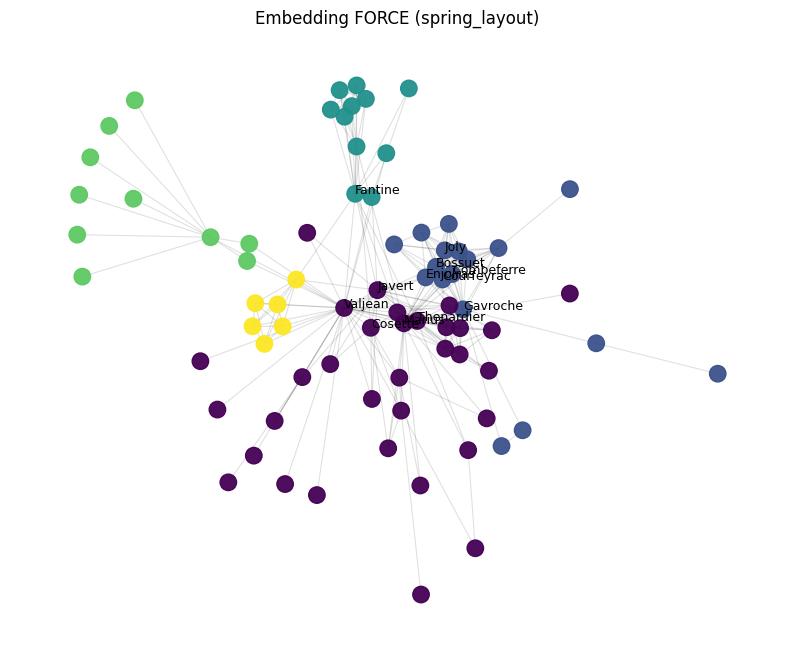

In [10]:
plot_embedding(
    force_df,
    title="Embedding FORCE (spring_layout)",
    annotate_nodes=top_nodes,
    color_by=node_colors,
    edge_alpha=0.12,
)

### Comentario

El layout FORCE suele preservar muy bien la **estructura visual local**:
quién está cerca de quién y qué zonas parecen comunidades.
Es ideal para una primera intuición geométrica del grafo.

## 5. Embedding 2: caminante aleatorio

Aquí construiremos un embedding muy simple inspirado en **DeepWalk / random walk embeddings**:

1. lanzamos muchos caminantes aleatorios,
2. contamos qué nodos aparecen cerca de otros dentro de una ventana,
3. construimos una matriz de coocurrencias,
4. reducimos esa matriz a 2 dimensiones con SVD.

No es una implementación industrial de node2vec, pero pedagógicamente explica muy bien la idea.

In [11]:
neighbors = {n: list(G.neighbors(n)) for n in G.nodes()}
weight_maps = {
    n: np.array([G[n][nbr].get("weight", 1.0) for nbr in neighbors[n]], dtype=float)
    for n in G.nodes()
}

for n in G.nodes():
    if len(weight_maps[n]) > 0:
        weight_maps[n] = weight_maps[n] / weight_maps[n].sum()

def random_walk(graph, start, walk_length=20):
    walk = [start]
    current = start
    for _ in range(walk_length - 1):
        nbrs = neighbors[current]
        if not nbrs:
            break
        probs = weight_maps[current]
        current = np.random.choice(nbrs, p=probs)
        walk.append(current)
    return walk

In [12]:
def build_cooccurrence_matrix(graph, num_walks=40, walk_length=20, window_size=3):
    nodes = list(graph.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    cooc = np.zeros((len(nodes), len(nodes)), dtype=float)

    for start in nodes:
        for _ in range(num_walks):
            walk = random_walk(graph, start, walk_length=walk_length)
            for i, center in enumerate(walk):
                left = max(0, i - window_size)
                right = min(len(walk), i + window_size + 1)
                for j in range(left, right):
                    if i == j:
                        continue
                    context = walk[j]
                    cooc[idx[center], idx[context]] += 1.0
    return nodes, cooc

rw_nodes, cooc = build_cooccurrence_matrix(
    G,
    num_walks=50,
    walk_length=24,
    window_size=3,
)

cooc.shape, cooc.sum()

((77, 77), np.float64(508200.0))

In [13]:
# PPMI sencilla para que la matriz recoja asociación y no solo frecuencia bruta
def ppmi_matrix(X, eps=1e-12):
    total = X.sum()
    row_sum = X.sum(axis=1, keepdims=True)
    col_sum = X.sum(axis=0, keepdims=True)

    p_ij = X / total
    p_i = row_sum / total
    p_j = col_sum / total

    pmi = np.log((p_ij + eps) / (p_i @ p_j + eps))
    ppmi = np.maximum(pmi, 0.0)
    return ppmi

ppmi = ppmi_matrix(cooc)
ppmi[:3, :3]

array([[2.58339583, 2.88479721, 2.09394337],
       [2.88479721, 1.99375472, 2.43753946],
       [2.09394337, 2.43753946, 1.93922515]])

In [14]:
svd_rw = TruncatedSVD(n_components=2, random_state=SEED)
rw_emb = svd_rw.fit_transform(ppmi)

rw_df = pd.DataFrame(rw_emb, index=rw_nodes, columns=["x", "y"])
rw_df.head()

,x,y
Napoleon,7.480728,-0.174575
Myriel,8.471849,-0.200289
MlleBaptistine,6.728072,-0.126506
MmeMagloire,6.769348,-0.130473
CountessDeLo,7.374997,-0.118717


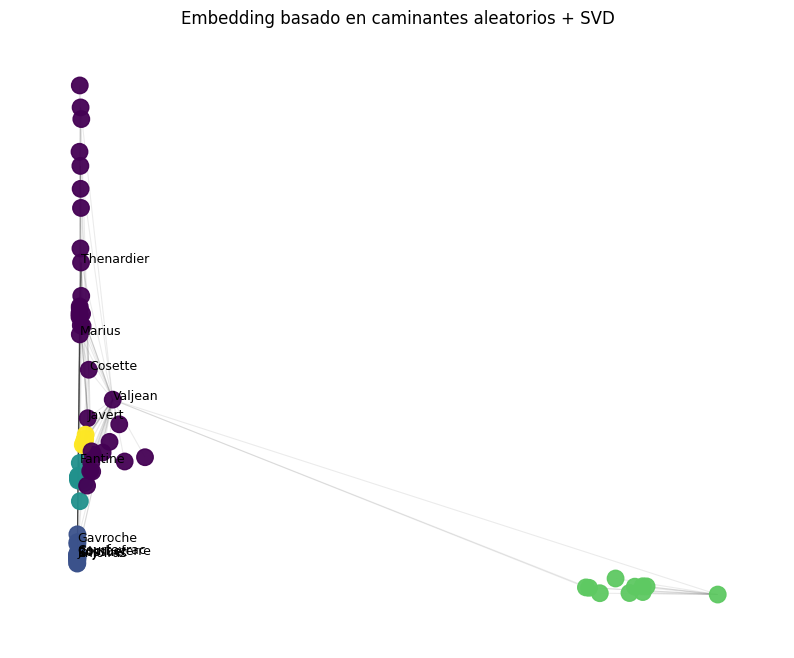

In [15]:
plot_embedding(
    rw_df,
    title="Embedding basado en caminantes aleatorios + SVD",
    annotate_nodes=top_nodes,
    color_by=[node_to_community[n] for n in rw_df.index],
    edge_alpha=0.08,
)

### Comentario

Este embedding intenta preservar **similitud de contexto estructural**:

- dos nodos pueden quedar cerca no solo porque estén conectados directamente,
- sino porque el caminante los visita en entornos parecidos.

Eso ya se parece más a la filosofía de embeddings de grafos modernos.

## 6. Embedding 3: PageRank personalizado

Ahora construiremos, para cada nodo `u`, un vector:

- arrancamos un PageRank personalizado centrado en `u`,
- obtenemos una distribución de probabilidad sobre todos los nodos,
- ese vector describe "cómo se difunde la influencia" desde `u`.

Eso produce un embedding de dimensión `N` (número de nodos), que luego reducimos a 2D con SVD.

In [16]:
nodes = list(G.nodes())
ppr_matrix = np.zeros((len(nodes), len(nodes)), dtype=float)

for i, source in enumerate(nodes):
    personalization = {n: 0.0 for n in nodes}
    personalization[source] = 1.0
    ppr = nx.pagerank(
        G,
        alpha=0.85,
        personalization=personalization,
        weight="weight",
    )
    ppr_matrix[i, :] = [ppr[n] for n in nodes]

ppr_matrix.shape

(77, 77)

In [17]:
svd_ppr = TruncatedSVD(n_components=2, random_state=SEED)
ppr_emb = svd_ppr.fit_transform(ppr_matrix)

ppr_df = pd.DataFrame(ppr_emb, index=nodes, columns=["x", "y"])
ppr_df.head()

,x,y
Napoleon,0.186172,0.229695
Myriel,0.215692,0.259527
MlleBaptistine,0.204282,0.211699
MmeMagloire,0.205543,0.220208
CountessDeLo,0.186172,0.229695


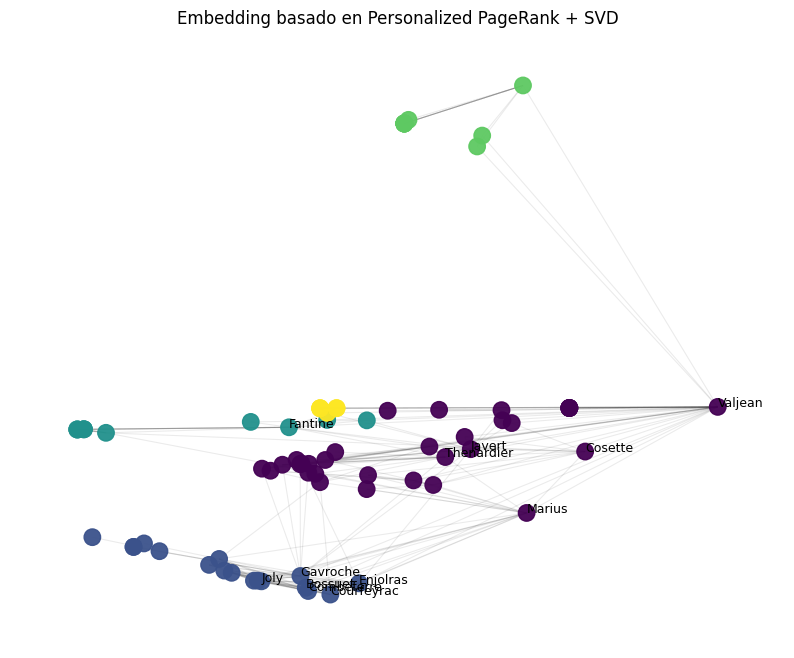

In [18]:
plot_embedding(
    ppr_df,
    title="Embedding basado en Personalized PageRank + SVD",
    annotate_nodes=top_nodes,
    color_by=[node_to_community[n] for n in ppr_df.index],
    edge_alpha=0.08,
)

### Comentario

El embedding por Personalized PageRank incorpora una noción de:

- **importancia global**,
- **accesibilidad por difusión**,
- y **proximidad estructural más allá de la vecindad inmediata**.

Suele ser más estable que un layout puramente visual y transmite una geometría ligada a procesos de paseo aleatorio con reinicio.

## 7. Comparación cuantitativa sencilla

Una comparación rápida: si dos embeddings son parecidos, las distancias entre nodos tenderán a correlacionarse.

In [19]:
def pairwise_distances(df):
    X = df.loc[node_order, ["x", "y"]].to_numpy()
    diff = X[:, None, :] - X[None, :, :]
    D = np.sqrt((diff ** 2).sum(axis=2))
    return D

D_force = pairwise_distances(force_df)
D_rw = pairwise_distances(rw_df.reindex(node_order))
D_ppr = pairwise_distances(ppr_df.reindex(node_order))

def upper_triangle_values(M):
    return M[np.triu_indices_from(M, k=1)]

comparison = pd.DataFrame({
    "force_vs_rw": [np.corrcoef(upper_triangle_values(D_force), upper_triangle_values(D_rw))[0, 1]],
    "force_vs_ppr": [np.corrcoef(upper_triangle_values(D_force), upper_triangle_values(D_ppr))[0, 1]],
    "rw_vs_ppr": [np.corrcoef(upper_triangle_values(D_rw), upper_triangle_values(D_ppr))[0, 1]],
})

comparison.T.rename(columns={0: "correlación_distancias"})

,correlación_distancias
force_vs_rw,0.528450
force_vs_ppr,0.598808
rw_vs_ppr,0.844727


## 8. Tabla final con coordenadas de ejemplo

In [20]:
final_df = pd.DataFrame(index=node_order)
final_df["community"] = [node_to_community[n] for n in node_order]
final_df["degree"] = [degrees[n] for n in node_order]
final_df["force_x"] = force_df.loc[node_order, "x"].values
final_df["force_y"] = force_df.loc[node_order, "y"].values
final_df["rw_x"] = rw_df.loc[node_order, "x"].values
final_df["rw_y"] = rw_df.loc[node_order, "y"].values
final_df["ppr_x"] = ppr_df.loc[node_order, "x"].values
final_df["ppr_y"] = ppr_df.loc[node_order, "y"].values

final_df.sort_values("degree", ascending=False).head(15)

,community,degree,force_x,force_y,rw_x,rw_y,ppr_x,ppr_y
Valjean,0,36,-0.052781,-0.021413,0.469219,1.816752,0.264136,0.007465
Gavroche,1,22,0.282226,-0.024599,0.001994,0.342626,0.160324,-0.125151
Marius,0,19,0.115644,-0.055039,0.033913,2.491663,0.216594,-0.075711
Javert,0,17,0.040945,0.017423,0.138653,1.624502,0.202705,-0.025698
Thenardier,0,16,0.152993,-0.049890,0.050514,3.235793,0.196366,-0.031861
Enjolras,1,15,0.176770,0.045308,0.001693,0.191598,0.174916,-0.130893
Fantine,2,15,-0.021752,0.228278,0.033849,1.161395,0.157491,-0.008526
Bossuet,1,13,0.206199,0.068452,0.000784,0.200916,0.161646,-0.134390
Courfeyrac,1,13,0.224620,0.040736,0.000978,0.219661,0.167772,-0.139689
Joly,1,12,0.230865,0.104576,0.000618,0.199962,0.150639,-0.129317


## 9. Ideas para discusión en clase

1. **¿Un layout es realmente un embedding?**  
   Conceptualmente sí: asigna vectores a nodos.  
   Metodológicamente, no siempre se considera igual que un embedding aprendido.

2. **FORCE vs random walk**  
   - FORCE enfatiza visualización y estructura local.  
   - Random walk enfatiza coocurrencia estructural.

3. **Random walk vs PageRank**  
   - ambos usan difusión,
   - pero Personalized PageRank introduce reinicio y una interpretación probabilística muy limpia.

4. **¿Qué pasa si aumentamos el tamaño de ventana, el número de walks o el parámetro `alpha`?**  
   Cambia la escala de vecindad que el embedding captura.

5. **Posible extensión**  
   Comparar con:
   - Laplacian eigenmaps,
   - node2vec,
   - embeddings aprendidos con una GNN.

## 10. Conclusión

Con un solo grafo pequeño y narrativamente atractivo hemos visto tres ideas centrales:

- una **representación física** (FORCE),
- una **representación por contexto de caminatas**,
- una **representación por difusión tipo PageRank**.

Para una sesión docente, este notebook funciona bien porque:
- corre rápido,
- se puede plottear entero,
- y permite discutir intuición, probabilidad y estructura de red al mismo tiempo.